In [ ]:
# import h5py
# import numpy as np
# import pandas as pd

# # 1. Create your Metadata DataFrame
# df = pd.DataFrame({
#     'img_num': [249, 251, 252],
#     'label_name': ['R1', 'R2', 'G1'],
#     'table_key': ['table_0', 'table_1', 'table_2'] # This links to HDF5
# })

# 2. Create the HDF5 file and store your 204x204 tables
# with h5py.File('lettuce_data.h5', 'w') as hf:
#     for i in range(len(df)):
#         # Simulate a 204x204 table
#         data = np.random.rand(204, 204) 
        
#         # Store it using the key from the DataFrame
#         hf.create_dataset(df['table_key'][i], data=data, compression="gzip")

# print("Files created: 'metadata.csv' and 'lettuce_data.h5'")

In [ ]:
import sys
sys.path.append('C:/myProjects/phenomobile')

import importlib
import itertools
from pathlib import Path
import os
import pandas as pd
import h5py
import ast
import numpy as np



In [7]:
def get_table_for_row(row_index, dataframe, h5_path):
    key = dataframe.iloc[row_index]['table_key']
    with h5py.File(h5_path, 'r') as hf:
        data = hf[key][:]

        cols = hf[key].attrs['columns']
        idx = hf[key].attrs['index']
    
        # Recreate the exact same DataFrame
        restored_df = pd.DataFrame(data, columns=cols, index=idx)
        return restored_df 

# Example usage:
# restored_df = get_table_for_row(0, df, 'lettuce_data.h5')
# print(f"Loaded table shape: {restored_df.shape}") # (204, 204)

In [ ]:


pd.set_option('display.max_columns', None)

df_name='Anthocyanin_with_hs_051225-050226'
h5_file='ndi_tables_for_hyper_sp_imgs_dataset_20251201_20260204.h5'

root_dir="c:/myProjects/phenomobile"
df_path=f'{root_dir}/datasets/BneiAtarot'

df=pd.read_csv(f"{df_path}/{df_name}.csv")

ndi_tables_dir = Path("c:/myProjects/phenomobile/ndi_tables")
ndi_tables_dir.mkdir(parents=True, exist_ok=True)
h5_output_dir = ndi_tables_dir 

h5_path =f'{h5_output_dir}/{h5_file}'
print(h5_path)

c:\myProjects\phenomobile\ndi_tables/ndi_tables_for_hyper_sp_imgs_dataset_20251201_20260204.h5


In [20]:
df.head(1)

,img_num,label_name,longitude,latitude,acquisition date,FVC,ndvi_mean,ndvi_std,ndvi_median,gndvi_mean,evi_mean,lai_mean,table_key,category,Lettuce color,Leaf sample weight (mg),Sample disc weight (g),Anthocyanins OD-530 nm,Chlorophyll OD-657 nm,Chlorophyll interference,Anthocyanin,DATE,Illumination
0,242,C1,34.916279,32.02523,04-01-2026,0.121632,0.890786,0.049238,0.905654,0.890786,1.020209,3.573116,table_0_1774187719104763187,RED_Control_ids,RED,0.46,0.03,1.0863,0.8226,0.206,0.881,05/02/2026,Control-Sun


In [8]:
restored_df = get_table_for_row(0, df, h5_path)
print(f"Loaded table shape: {restored_df.shape}") # (204, 204)

Loaded table shape: (204, 204)


In [9]:
with h5py.File(h5_path, 'r') as hf:
    h5_keys=list(hf.keys())
    

In [10]:
def get_ndi_table_by_table_key(df_key,hdf5_path):
    try:
        with h5py.File(hdf5_path, 'r') as hf:
            if df_key not in list(hf.keys()):
                raise ValueError(f"Key {df_key} not found in HDF5 file")
            data = hf[df_key][:]

            cols = hf[df_key].attrs['columns']
            idx = hf[df_key].attrs['index']
        
            # Recreate the exact same DataFrame
            restored_df = pd.DataFrame(data, columns=cols, index=idx)
            return restored_df
    except Exception as e:
        print(f"Error reading HDF5 file: {e}")
        raise e

In [16]:
df_keys=df['table_key'].to_list()
dict_of_ndi_tables={}
for df_key in df_keys:
    #print(df_key)
    restored_ndi_table_df = get_ndi_table_by_table_key(df_key, h5_path)
    #print(f"Loaded table shape: {restored_ndi_table_df.shape}") # (204, 204)
    dict_of_ndi_tables[df_key] = restored_ndi_table_df

In [21]:
df.head(1)

,img_num,label_name,longitude,latitude,acquisition date,FVC,ndvi_mean,ndvi_std,ndvi_median,gndvi_mean,evi_mean,lai_mean,table_key,category,Lettuce color,Leaf sample weight (mg),Sample disc weight (g),Anthocyanins OD-530 nm,Chlorophyll OD-657 nm,Chlorophyll interference,Anthocyanin,DATE,Illumination
0,242,C1,34.916279,32.02523,04-01-2026,0.121632,0.890786,0.049238,0.905654,0.890786,1.020209,3.573116,table_0_1774187719104763187,RED_Control_ids,RED,0.46,0.03,1.0863,0.8226,0.206,0.881,05/02/2026,Control-Sun


In [28]:
dict_of_ndi_tables['table_0_1774187719104763187'].loc['397.32','400.20']

np.float32(0.14989698)

In [ ]:
#set the target
target='Anthocyanin'

tables_keys=list(dict_of_ndi_tables.keys())

#our assumption is that all the ndi tables have the same wavelength columns
wl=list(dict_of_ndi_tables[tables_keys[0]].columns)

#this dataframe will contain one ndi cell value from
# each ndi tables along the dataset . for example for ndi tuple :
# ('397.32','400.20') the df below will hold the value of 
# ndi_table_i_.loc['397.32','400.20'] for each ndi table i in the dataset
# where i here is the index for the table key in the dict_ndi_tables
# in addition we will add the target value for each row



#set the first ndi tuple
wl1_idx,wl2_idx=0,1
wl1,wl2=wl[wl1_idx],wl[wl2_idx]
ndi_tuple=(wl1,wl2)

# Pass the variables inside a list to the 'columns' parameter
df_of_one_ndi_tuple = pd.DataFrame(columns=["table_key",ndi_tuple, target])

for table_cur_key in tables_keys:
    #set the first table key
    #table_cur_key=tables_keys[0]

    #extract the ndi value for this tuple from the first table
    ndi_value=dict_of_ndi_tables[table_cur_key].loc[wl1,wl2]

    #get the target value for this table key
    target_value=df[df['table_key']==table_cur_key][target].item()

    #add the ndi value to the dataframe
    new_row = {'table_key': table_cur_key,
        ndi_tuple: ndi_value, target: target_value}

    df_of_one_ndi_tuple.loc[len(df_of_one_ndi_tuple)] = new_row


In [81]:
ndi_tuple

('397.32', '400.20')

In [58]:
df_of_one_ndi_tuple.head(1)

,table_key,"(397.32, 400.20)",Anthocyanin
0,table_0_1774187719104763187,0.149897,0.881


In [202]:
import src.ml.training
import src.ml.train_on_ndi_tables

importlib.reload(src.ml.train_on_ndi_tables)
importlib.reload(src.ml.training)

from src.ml.training import Training
from src.ml.train_on_ndi_tables import  TrainOnNdiTables   

In [204]:
# Initialize training
task="regression"
dataset_path=f"{df_path}/{df_name}.csv"
H5_FILE_PATH=h5_path
target='Anthocyanin'

ml =TrainOnNdiTables (
    dataset_name=dataset_path,
    target=target,
    config=None,
    task=task,
    model=None,
    logger=None,
    H5_FILE_PATH=H5_FILE_PATH
)


In [207]:
ml.compute_r2_score_for_ndi_cube()

best_wl1, best_wl2, best_r2 = ml.get_best_ndi_combination_r2()
print(f"Best combination: {best_wl1} and {best_wl2} with R² = {best_r2:.4f}")

Best combination: 577.96 and 580.90 with R² = 0.5940


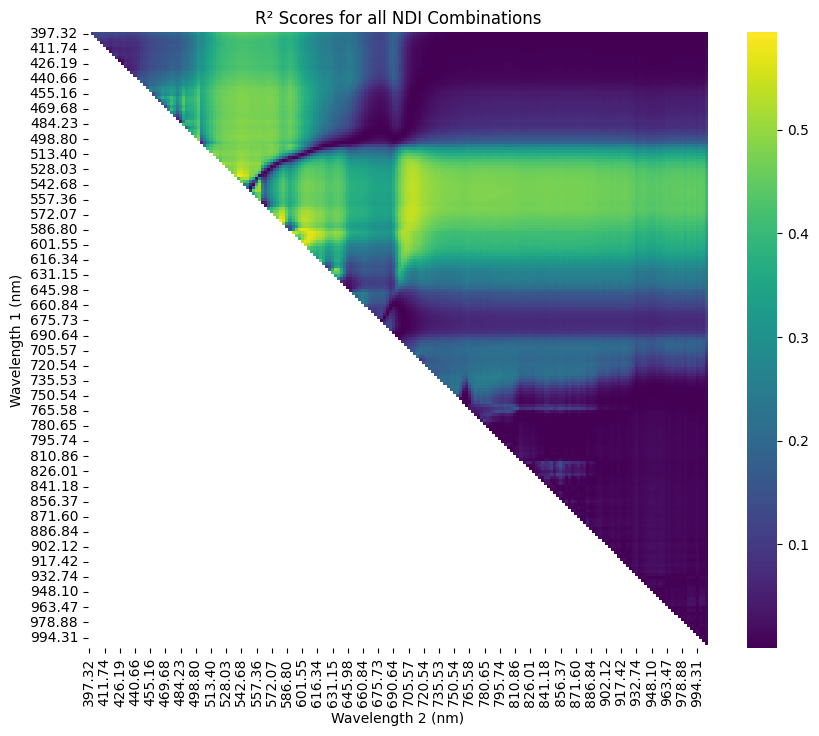

In [209]:
ml.plot_r2_results()

### sbm connection protocol

In [84]:
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

# Access the variables using os.environ
my_username = os.getenv('SMB_USERNAME')
my_password = os.getenv('SMB_PASSWORD')
print(my_username)

davidb


In [ ]:
import smbclient
from smbclient.shutil import copyfile
import concurrent.futures
from smbclient import listdir, open_file

# # Network monitoring
# netstat -an | grep 445   # SMB port connections


# Method 1: Using smbclient.shutil
from smbclient import shutil
import smbclient
 
# Register session (required!)
smbclient.register_session(
    server='10.26.94.14',
    username=my_username,
    password=my_password
)

 


In [88]:
# Method 2: Direct share access
try:
    files = smbclient.listdir('//10.26.94.14/PhenomobileData/DavidDataForTest/Phenomobile')
    print("Files in share:", files[:10])  # First 10 files
except Exception as e:
    print(f"Error accessing share: {e}")

Files in share: ['Rehovot', 'BneiAtarot', 'NeweYaar', 'Gevim_Sesami']


In [99]:
import time
import os
import smbclient
import smbprotocol.connection
from smbclient import register_session
from dotenv import load_dotenv

def monitor_credits(username, password, server_ip='10.26.94.14'):
    register_session(server=server_ip, username=username, password=password)
    
    print(f"Monitoring credits for {server_ip}...")
    
    try:
        # 1. Force activity to ensure the connection is indexed
        folder1, folder2 = 'PhenomobileData', 'DavidDataForTest'
        path = f"\\\\{server_ip}\\{folder1}\\{folder2}"
        smbclient.listdir(path) 
        
        # 2. Find the connection pool
        # We look for any dictionary in the connection module that holds Connection objects
        target_conn = None
        
        # In most versions, it's either Connection.connections or a global _connections
        connections_pool = None
        if hasattr(smbprotocol.connection.Connection, 'connections'):
            connections_pool = smbprotocol.connection.Connection.connections
        elif hasattr(smbprotocol.connection, '_connections'):
            connections_pool = smbprotocol.connection._connections
            
        if connections_pool:
            for key, conn_obj in connections_pool.items():
                if server_ip in str(key):
                    target_conn = conn_obj
                    break
        
        if not target_conn:
            print(f"Could not find an active connection object for {server_ip}.")
            return

        # 3. Monitor the Sequence Window
        for i in range(10):
            # sequence_window.low is the available credits
            available = target_conn.sequence_window.low
            maximum = target_conn.max_credits
            
            percent = (available / maximum * 100) if maximum > 0 else 0
            print(f"[{i+1}] Credits: {available}/{maximum} ({percent:.1f}%)")
            
            if available < 10:
                print("⚠️  Warning: Server is heavily loaded!")
                
            time.sleep(1)
            
    except Exception as e:
        print(f"Monitor failed: {e}")

# Run
load_dotenv()
monitor_credits(os.getenv('SMB_USERNAME'), os.getenv('SMB_PASSWORD'))

Monitoring credits for 10.26.94.14...
Could not find an active connection object for 10.26.94.14.
